# Bangladesh Budget Impact Analysis v3

This notebook evaluates whether Bangladesh national budgets were good for the country and people. It uses budget outlay data plus World Bank-sourced macro data. The included CSV is already populated with verified FRED table data where available, and the scripts can refresh from World Bank/FRED when internet is available.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm

DATA = Path('data')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 120)


## 2. Load combined dataset

In [2]:
df = pd.read_csv(DATA / 'bangladesh_budget_macro_combined_2010_2025.csv')
df


,FiscalYear,Year,BudgetCroreBDT,BudgetGrowthPct,SourceNote,InflationCPIAnnualPct,GDPCurrentUSD,GDPCurrentUSDBillion,GDPUSDNominalGrowthPct,ExchangeRateMarketEstimatedBDTPerUSD,ExchangeRateGrowthPct,YouthUnemploymentPct,MacroSourceNote,RealBudgetGrowthApproxPct
0,2010-11,2010,132170,NaN,Historical national budget outlay; FY2025-26 c...,8.126676,1.152755e+11,115.275540,NaN,69.649292,NaN,6.289,"CPI, GDP, and youth unemployment are World Ban...",NaN
1,2011-12,2011,161214,21.974730,Historical national budget outlay; FY2025-26 c...,11.395165,1.286075e+11,128.607482,11.565283,74.152400,6.465404,7.429,"CPI, GDP, and youth unemployment are World Ban...",10.579564
2,2012-13,2012,191738,18.933839,Historical national budget outlay; FY2025-26 c...,6.217504,1.333107e+11,133.310748,3.657070,81.862658,10.397854,8.538,"CPI, GDP, and youth unemployment are World Ban...",12.716335
3,2013-14,2013,222491,16.039074,Historical national budget outlay; FY2025-26 c...,7.530406,1.499990e+11,149.998957,12.518278,78.103235,-4.592354,9.674,"CPI, GDP, and youth unemployment are World Ban...",8.508668
4,2014-15,2014,250560,12.615791,Historical national budget outlay; FY2025-26 c...,6.991639,1.728866e+11,172.886612,15.258542,77.641408,-0.591303,10.122,"CPI, GDP, and youth unemployment are World Ban...",5.624152
5,2015-16,2015,295100,17.776181,Historical national budget outlay; FY2025-26 c...,6.194280,1.951466e+11,195.146609,12.875489,77.946908,0.393476,10.561,"CPI, GDP, and youth unemployment are World Ban...",11.581901
6,2016-17,2016,340605,15.420197,Historical national budget outlay; FY2025-26 c...,5.513526,2.652245e+11,265.224516,35.910389,78.468092,0.668639,10.956,"CPI, GDP, and youth unemployment are World Ban...",9.906671
7,2017-18,2017,400266,17.516184,Historical national budget outlay; FY2025-26 c...,5.702070,2.937324e+11,293.732447,10.748603,80.437542,2.509874,12.101,"CPI, GDP, and youth unemployment are World Ban...",11.814114
8,2018-19,2018,464573,16.066066,Historical national budget outlay; FY2025-26 c...,5.543621,3.213628e+11,321.362752,9.406624,83.466202,3.765232,11.907,"CPI, GDP, and youth unemployment are World Ban...",10.522445
9,2019-20,2019,523190,12.617393,Historical national budget outlay; FY2025-26 c...,5.591996,3.512317e+11,351.231655,9.294451,84.453523,1.182899,11.742,"CPI, GDP, and youth unemployment are World Ban...",7.025396


## 3. Check missing values

In [3]:
df.isna().sum().sort_values(ascending=False)


ExchangeRateMarketEstimatedBDTPerUSD    2
RealBudgetGrowthApproxPct               2
BudgetGrowthPct                         1
InflationCPIAnnualPct                   1
GDPCurrentUSD                           1
GDPCurrentUSDBillion                    1
GDPUSDNominalGrowthPct                  1
ExchangeRateGrowthPct                   1
FiscalYear                              0
Year                                    0
BudgetCroreBDT                          0
SourceNote                              0
YouthUnemploymentPct                    0
MacroSourceNote                         0
dtype: int64

## 4. Budget growth vs inflation

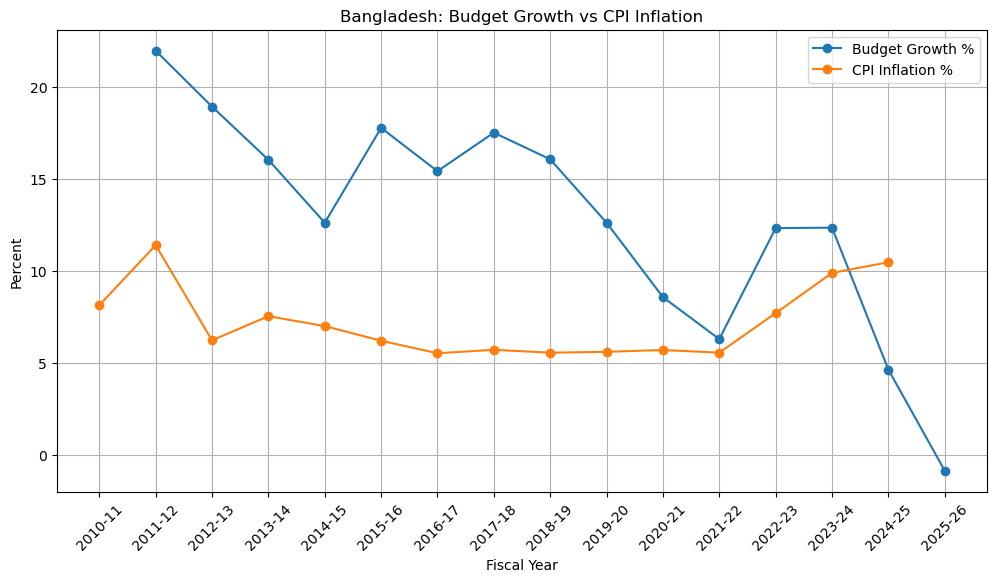

In [4]:
plt.plot(df['FiscalYear'], df['BudgetGrowthPct'], marker='o', label='Budget Growth %')
plt.plot(df['FiscalYear'], df['InflationCPIAnnualPct'], marker='o', label='CPI Inflation %')
plt.title('Bangladesh: Budget Growth vs CPI Inflation')
plt.xlabel('Fiscal Year')
plt.ylabel('Percent')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()


## 5. Real budget growth approximation

Approximation: nominal budget growth minus CPI inflation. Positive values mean budget grew faster than consumer prices; negative values mean inflation ate up budget growth.

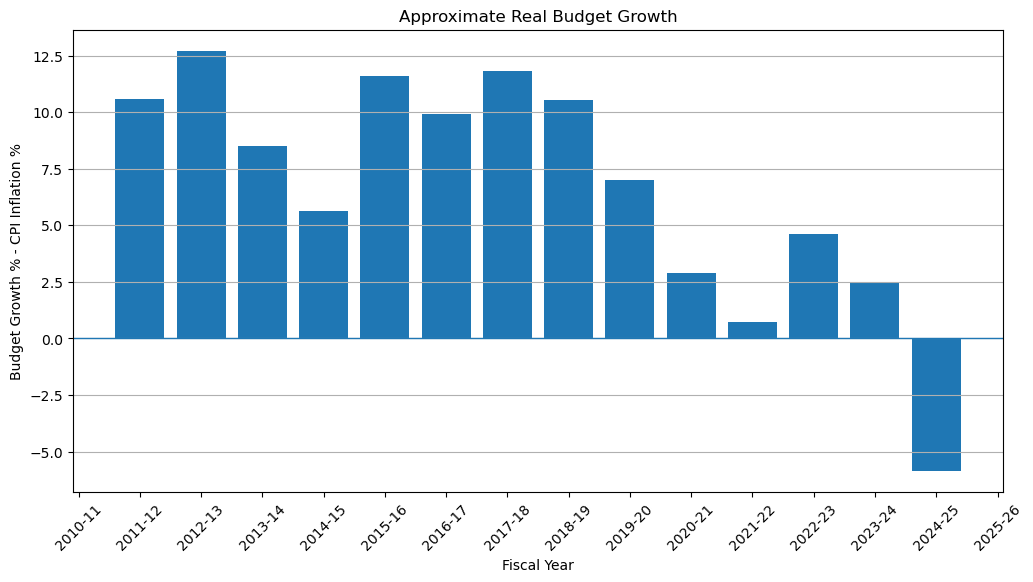

In [5]:
plt.axhline(0, linewidth=1)
plt.bar(df['FiscalYear'], df['RealBudgetGrowthApproxPct'])
plt.title('Approximate Real Budget Growth')
plt.xlabel('Fiscal Year')
plt.ylabel('Budget Growth % - CPI Inflation %')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


## 6. GDP and exchange-rate pressure

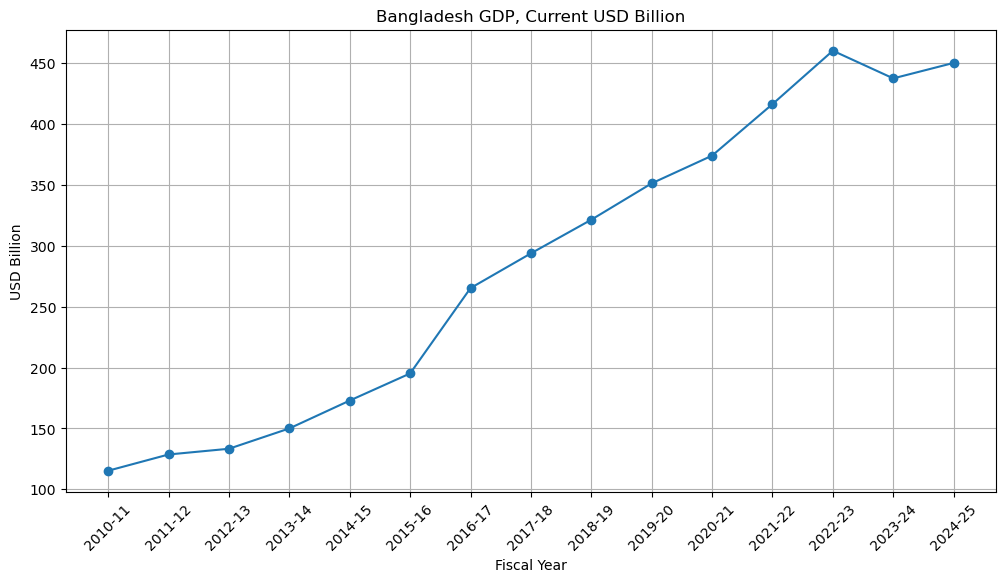

In [6]:
plt.plot(df['FiscalYear'], df['GDPCurrentUSDBillion'], marker='o')
plt.title('Bangladesh GDP, Current USD Billion')
plt.xlabel('Fiscal Year')
plt.ylabel('USD Billion')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


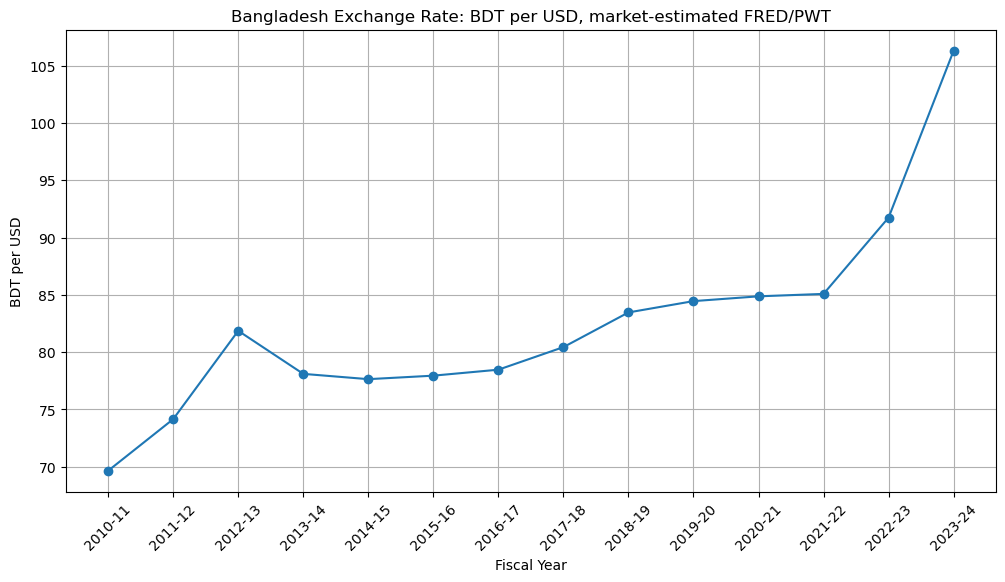

In [8]:
plt.plot(df['FiscalYear'], df['ExchangeRateMarketEstimatedBDTPerUSD'], marker='o')
plt.title('Bangladesh Exchange Rate: BDT per USD, market-estimated FRED/PWT')
plt.xlabel('Fiscal Year')
plt.ylabel('BDT per USD')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## 7. Correlation matrix

Correlation is not causation, but it helps identify relationships for deeper investigation.

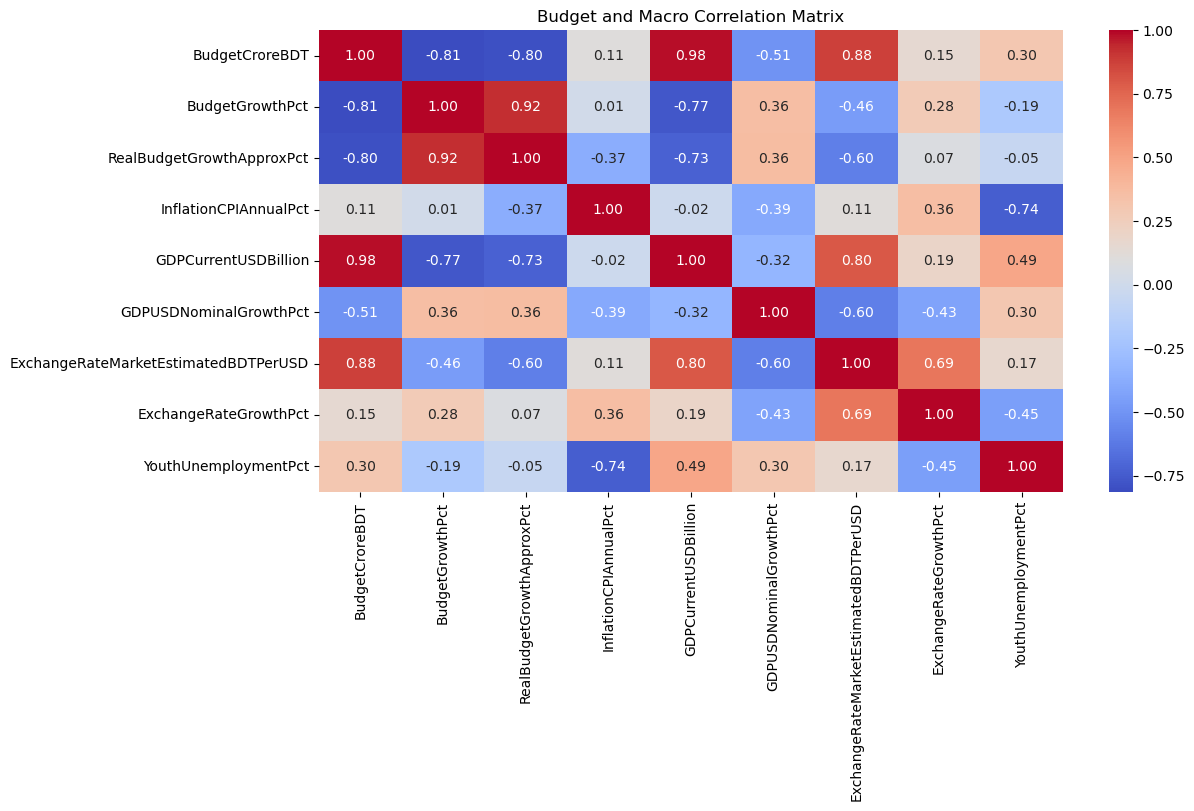

,InflationCPIAnnualPct,GDPUSDNominalGrowthPct
InflationCPIAnnualPct,1.000000,-0.392647
ExchangeRateGrowthPct,0.359358,-0.427844
ExchangeRateMarketEstimatedBDTPerUSD,0.113993,-0.600922
BudgetCroreBDT,0.105107,-0.506835
BudgetGrowthPct,0.014102,0.358334
GDPCurrentUSDBillion,-0.016457,-0.322967
RealBudgetGrowthApproxPct,-0.371181,0.363095
GDPUSDNominalGrowthPct,-0.392647,1.000000
YouthUnemploymentPct,-0.739205,0.299501


In [9]:
corr_cols = [
    'BudgetCroreBDT','BudgetGrowthPct','RealBudgetGrowthApproxPct','InflationCPIAnnualPct',
    'GDPCurrentUSDBillion','GDPUSDNominalGrowthPct','ExchangeRateMarketEstimatedBDTPerUSD',
    'ExchangeRateGrowthPct','YouthUnemploymentPct'
]
corr = df[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Budget and Macro Correlation Matrix')
plt.show()
corr[['InflationCPIAnnualPct','GDPUSDNominalGrowthPct']].sort_values('InflationCPIAnnualPct', ascending=False)


## 8. Regression: inflation drivers

This model asks whether inflation is associated with budget growth, exchange-rate change, youth unemployment, and GDP growth. The dataset is small, so read this as exploratory analysis.

In [10]:
reg = df[['InflationCPIAnnualPct','BudgetGrowthPct','ExchangeRateGrowthPct','GDPUSDNominalGrowthPct','YouthUnemploymentPct']].dropna()
X = reg[['BudgetGrowthPct','ExchangeRateGrowthPct','GDPUSDNominalGrowthPct','YouthUnemploymentPct']]
X = sm.add_constant(X)
y = reg['InflationCPIAnnualPct']
ols = sm.OLS(y, X).fit()
print(ols.summary())


                              OLS Regression Results                             
Dep. Variable:     InflationCPIAnnualPct   R-squared:                       0.743
Model:                               OLS   Adj. R-squared:                  0.629
Method:                    Least Squares   F-statistic:                     6.518
Date:                   Sun, 14 Jun 2026   Prob (F-statistic):            0.00954
Time:                           03:32:01   Log-Likelihood:                -19.692
No. Observations:                     14   AIC:                             49.38
Df Residuals:                          9   BIC:                             52.58
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/Users/jerin/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


## 9. Budget Effectiveness Score v3

Score components:

- Inflation control: lower CPI inflation is better
- Growth: higher nominal USD GDP growth is better, as a proxy until real GDP growth is refreshed from World Bank API
- Employment: lower youth unemployment is better
- Real budget growth: positive real budget growth is better

This is a portfolio scoring model, not an official government measure.

In [11]:
score = df.copy()

def norm_positive(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min())

def norm_negative(s):
    s = s.astype(float)
    return 1 - ((s - s.min()) / (s.max() - s.min()))

score['InflationControlScore'] = norm_negative(score['InflationCPIAnnualPct'])
score['GrowthScore'] = norm_positive(score['GDPUSDNominalGrowthPct'])
score['EmploymentScore'] = norm_negative(score['YouthUnemploymentPct'])
score['RealBudgetGrowthScore'] = norm_positive(score['RealBudgetGrowthApproxPct'])

score['BudgetEffectivenessScoreV3'] = 100 * (
    0.35 * score['InflationControlScore'] +
    0.25 * score['GrowthScore'] +
    0.20 * score['EmploymentScore'] +
    0.20 * score['RealBudgetGrowthScore']
)

def label(v):
    if pd.isna(v): return 'Insufficient data'
    if v >= 80: return 'Strong'
    if v >= 65: return 'Moderate'
    if v >= 50: return 'Weak'
    return 'Poor'

score['BudgetQualityLabel'] = score['BudgetEffectivenessScoreV3'].apply(label)
score[['FiscalYear','BudgetCroreBDT','InflationCPIAnnualPct','GDPUSDNominalGrowthPct','YouthUnemploymentPct','RealBudgetGrowthApproxPct','BudgetEffectivenessScoreV3','BudgetQualityLabel']]


,FiscalYear,BudgetCroreBDT,InflationCPIAnnualPct,GDPUSDNominalGrowthPct,YouthUnemploymentPct,RealBudgetGrowthApproxPct,BudgetEffectivenessScoreV3,BudgetQualityLabel
0,2010-11,132170,8.126676,NaN,6.289,NaN,NaN,Insufficient data
1,2011-12,161214,11.395165,11.565283,7.429,10.579564,44.623584,Poor
2,2012-13,191738,6.217504,3.657070,8.538,12.716335,69.809512,Moderate
3,2013-14,222491,7.530406,12.518278,9.674,8.508668,59.723312,Weak
4,2014-15,250560,6.991639,15.258542,10.122,5.624152,60.250874,Weak
5,2015-16,295100,6.194280,12.875489,10.561,11.581901,68.735260,Moderate
6,2016-17,340605,5.513526,35.910389,10.956,9.906671,83.979483,Strong
7,2017-18,400266,5.702070,10.748603,12.101,11.814114,66.325468,Moderate
8,2018-19,464573,5.543621,9.406624,11.907,10.522445,65.595172,Moderate
9,2019-20,523190,5.591996,9.294451,11.742,7.025396,61.929511,Weak


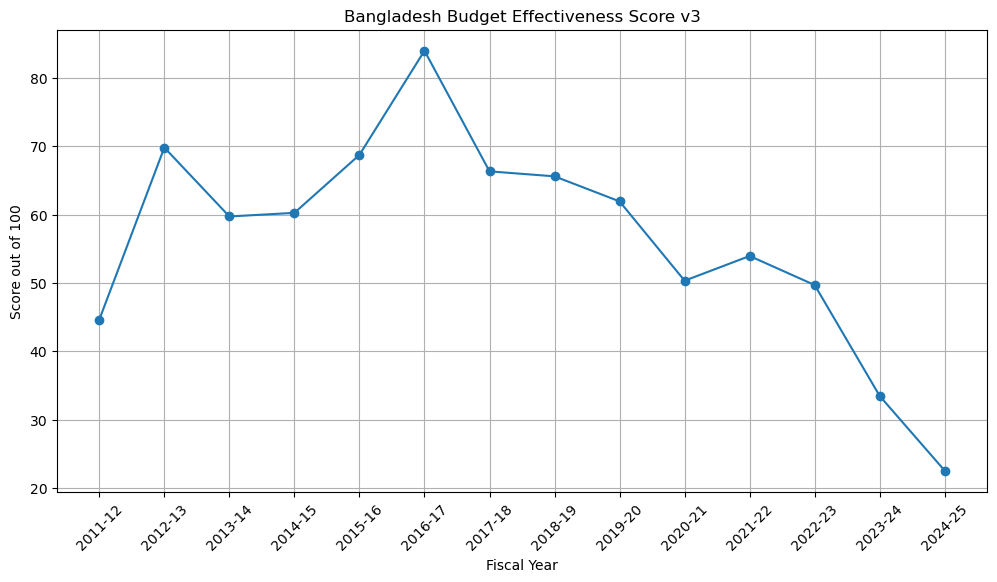

In [12]:
plt.plot(score['FiscalYear'], score['BudgetEffectivenessScoreV3'], marker='o')
plt.title('Bangladesh Budget Effectiveness Score v3')
plt.xlabel('Fiscal Year')
plt.ylabel('Score out of 100')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## 10. Machine-learning feature importance

Target: CPI inflation. Features: budget growth, exchange-rate growth, GDP growth, youth unemployment. Because the dataset is small, this is for portfolio demonstration only.

In [13]:
ml = df[['InflationCPIAnnualPct','BudgetGrowthPct','ExchangeRateGrowthPct','GDPUSDNominalGrowthPct','YouthUnemploymentPct']].dropna()
X = ml[['BudgetGrowthPct','ExchangeRateGrowthPct','GDPUSDNominalGrowthPct','YouthUnemploymentPct']]
y = ml['InflationCPIAnnualPct']

rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=2)
rf.fit(X, y)

importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
importance


,Feature,Importance
3,YouthUnemploymentPct,0.669232
1,ExchangeRateGrowthPct,0.157270
2,GDPUSDNominalGrowthPct,0.124954
0,BudgetGrowthPct,0.048544


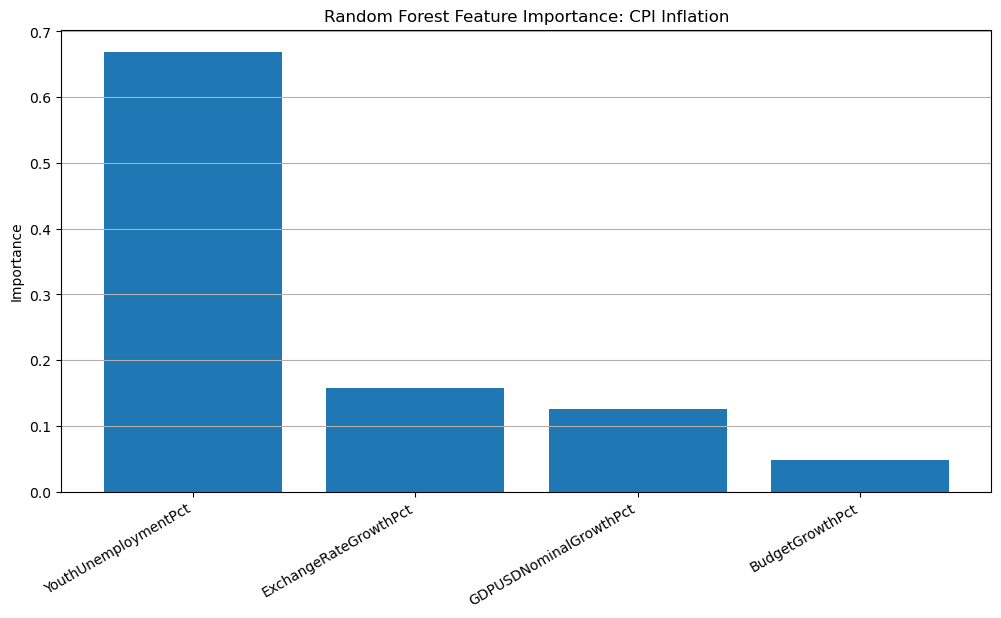

In [14]:
plt.bar(importance['Feature'], importance['Importance'])
plt.title('Random Forest Feature Importance: CPI Inflation')
plt.ylabel('Importance')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y')
plt.show()


## 11. Scenario simulator

Change these numbers to test a hypothetical budget year.

In [15]:
scenario = pd.DataFrame({
    'BudgetGrowthPct': [8.0],
    'ExchangeRateGrowthPct': [5.0],
    'GDPUSDNominalGrowthPct': [6.0],
    'YouthUnemploymentPct': [9.5]
})
scenario['PredictedInflationPct'] = rf.predict(scenario[X.columns])
scenario


,BudgetGrowthPct,ExchangeRateGrowthPct,GDPUSDNominalGrowthPct,YouthUnemploymentPct,PredictedInflationPct
0,8.0,5.0,6.0,9.5,7.506589


## 12. What data should be added next?

The model becomes much stronger when you add verified annual data for revenue, deficit, ADP, health, education, social safety net, interest payments, reserves, real GDP growth, and total unemployment from official budget PDFs / World Bank API.